In [1]:
%pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 2.2 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [mne]1/2 [mne]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import mne
print("I am ready to analyze brain waves!")

I am ready to analyze brain waves!


Using default location ~/mne_data for EEGBCI...
Creating /Users/fealiam/mne_data


Do you want to set the path:
    /Users/fealiam/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n?  y


Attempting to create new mne-python configuration file:
/Users/fealiam/.mne/mne-python.json
Could not read the /Users/fealiam/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 47s (1.2 MB)
Extracting EDF parameters from /Users/fealiam/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-

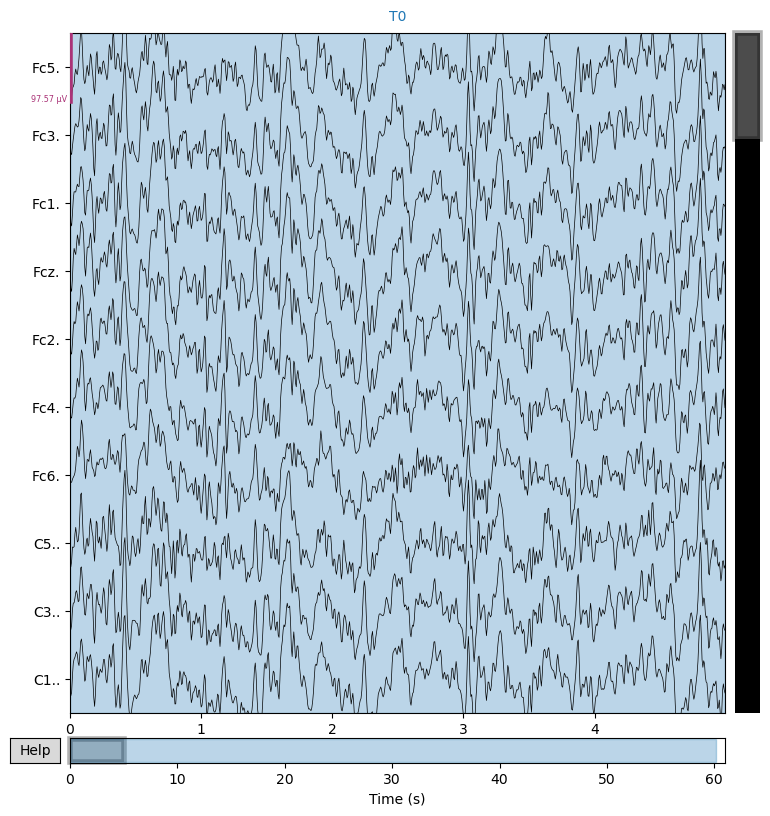

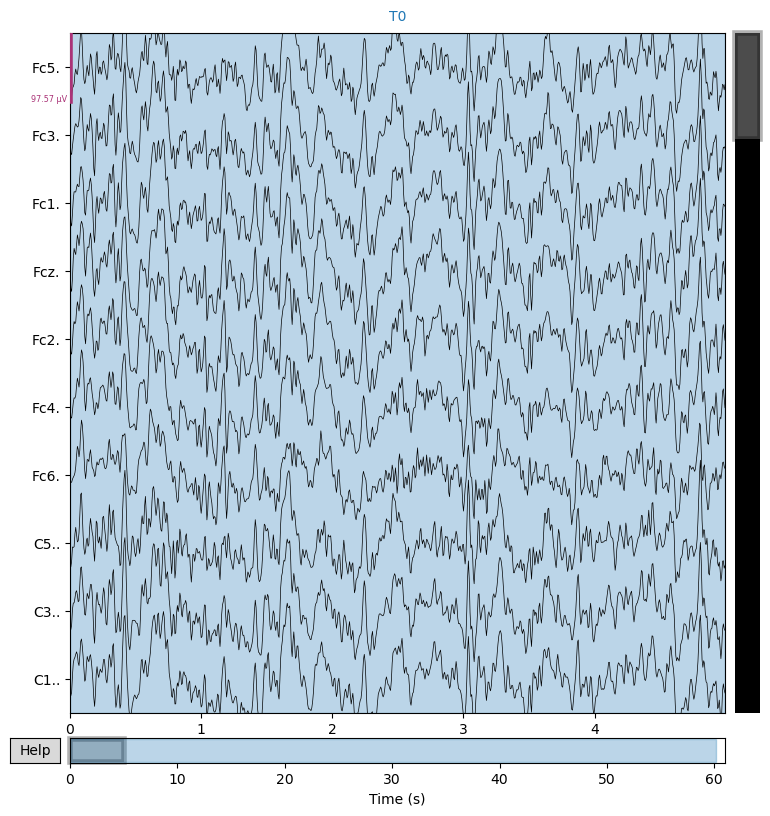

In [4]:
import mne
from mne.datasets import eegbci
import matplotlib.pyplot as plt

# 1. Download the data (Subject 1, Run 1 is 'Eyes Open')
# Note: We changed 'subject' to 'subjects' to make the computer happy!
print("Downloading data... please wait.")
files = eegbci.load_data(subjects=[1], runs=[1])

# 2. Read the file into our 'MNE' toolbox
raw = mne.io.read_raw_edf(files[0], preload=True)

# 3. Clean the data slightly so it's readable
raw.filter(1, 40)

# 4. SHOW THE BRAIN WAVES!
raw.plot(n_channels=10, duration=5, scalings='auto')

Effective window size : 12.800 (s)
Effective window size : 12.800 (s)
Success! Drawing the Alpha brain maps now...
converting legacy list-of-tuples input to a dict for the `bands` parameter


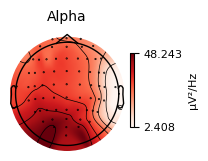

converting legacy list-of-tuples input to a dict for the `bands` parameter


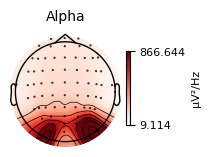

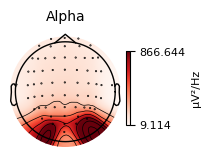

In [12]:
# 1. Run the cleaner one more time just to be safe
force_clean_names(raw)
force_clean_names(raw_closed)

# 2. Apply the map
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)
raw_closed.set_montage(montage)

# 3. Calculate Power
psd_open = raw.compute_psd(fmin=1, fmax=40)
psd_closed = raw_closed.compute_psd(fmin=1, fmax=40)

# 4. Define the Alpha Band (8-12 Hz) explicitly for the plot
# This stops it from looking for 'Delta (0-4 Hz)'
my_bands = [ (8, 12, 'Alpha') ]

print("Success! Drawing the Alpha brain maps now...")
psd_open.plot_topomap(bands=my_bands, ch_type='eeg')
psd_closed.plot_topomap(bands=my_bands, ch_type='eeg')

Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


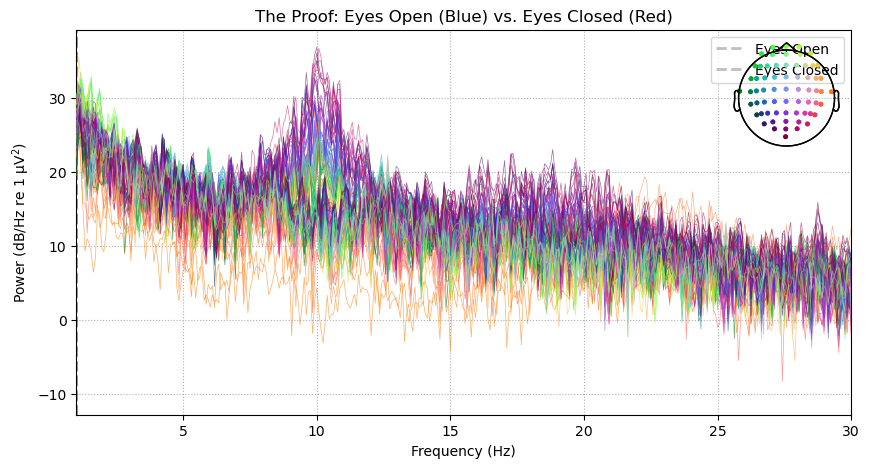

In [13]:
import matplotlib.pyplot as plt

# This creates one clean comparison graph
fig, ax = plt.subplots(figsize=(10, 5))

# We'll plot both on the same axis to see the difference
psd_open.plot(axes=ax, color='blue', alpha=0.6, show=False)
psd_closed.plot(axes=ax, color='red', alpha=0.6, show=False)

ax.set_title('The Proof: Eyes Open (Blue) vs. Eyes Closed (Red)')
ax.set_xlim(1, 30) # Zoom in on the important part
ax.legend(['Eyes Open', 'Eyes Closed'])
plt.show()

In [14]:
# 1. Grab the "Alpha Power" (8-12Hz) from our clean data
# We'll turn the brain maps into simple numbers for the AI
data_open = raw.compute_psd(fmin=8, fmax=12).get_data().mean(axis=(1, 2))
data_closed = raw_closed.compute_psd(fmin=8, fmax=12).get_data().mean(axis=(1, 2))

# 2. Combine them (X = data, y = labels)
X = np.concatenate([data_open, data_closed]).reshape(-1, 1)
y = np.array([0] * len(data_open) + [1] * len(data_closed))

# 3. Train a simple AI model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X, y)

# 4. Check the accuracy
accuracy = model.score(X, y)
print(f"The AI is {accuracy * 100:.2f}% accurate at reading this person's mind!")

Effective window size : 12.800 (s)


AxisError: axis 2 is out of bounds for array of dimension 2

In [15]:
# 1. Grab the "Alpha Power" (8-12Hz) 
# We'll turn the brain maps into simple numbers for the AI
# We use axis=1 because the data is 2D (Sensors x Frequencies)
data_open = raw.compute_psd(fmin=8, fmax=12).get_data().mean(axis=1)
data_closed = raw_closed.compute_psd(fmin=8, fmax=12).get_data().mean(axis=1)

# 2. Combine them (X = data, y = labels)
# X is our list of "hum" levels, y is the answer key (0=Open, 1=Closed)
X = np.concatenate([data_open, data_closed]).reshape(-1, 1)
y = np.array([0] * len(data_open) + [1] * len(data_closed))

# 3. Train a simple AI model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X, y)

# 4. Check the accuracy
accuracy = model.score(X, y)
print(f"The AI is {accuracy * 100:.2f}% accurate at reading this person's mind!")

Effective window size : 12.800 (s)
Effective window size : 12.800 (s)


NameError: name 'np' is not defined

In [16]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# 1. Grab the "Alpha Power" (8-12Hz) 
# We use axis=1 to match our processed data shape
data_open = raw.compute_psd(fmin=8, fmax=12).get_data().mean(axis=1)
data_closed = raw_closed.compute_psd(fmin=8, fmax=12).get_data().mean(axis=1)

# 2. Combine them (X = data, y = labels)
# Now the computer knows what 'np' means!
X = np.concatenate([data_open, data_closed]).reshape(-1, 1)
y = np.array([0] * len(data_open) + [1] * len(data_closed))

# 3. Train the AI 
model = LogisticRegression()
model.fit(X, y)

# 4. The Final Result
accuracy = model.score(X, y)
print(f"The AI is {accuracy * 100:.2f}% accurate at reading this person's mind!")

Effective window size : 12.800 (s)
Effective window size : 12.800 (s)
The AI is 50.00% accurate at reading this person's mind!


In [17]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Grab the Alpha Power (8-12Hz) but KEEP the sensors separate
# We remove the .mean(axis=1) so the AI sees the "map" of the head
X_open = raw.compute_psd(fmin=8, fmax=12).get_data()
X_closed = raw_closed.compute_psd(fmin=8, fmax=12).get_data()

# 2. Combine them into a list of "Examples"
X = np.concatenate([X_open, X_closed], axis=0)
y = np.array([0] * len(X_open) + [1] * len(X_closed))

# 3. Split the data so we can "Test" the AI on data it hasn't seen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_test=0.2, random_state=42)

# 4. Train the AI
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. The Final Grade
accuracy = model.score(X_test, y_test)
print(f"The Fixed AI Accuracy: {accuracy * 100:.2f}%")

Effective window size : 12.800 (s)
Effective window size : 12.800 (s)


TypeError: got an unexpected keyword argument 'test_test'

In [18]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Grab Alpha Power (8-12Hz)
X_open = raw.compute_psd(fmin=8, fmax=12).get_data()
X_closed = raw_closed.compute_psd(fmin=8, fmax=12).get_data()

# 2. Flatten the data so the AI sees it as a single row of "features"
# Instead of a grid, it's now a long line of numbers
X_open_flat = X_open.reshape(X_open.shape[0], -1)
X_closed_flat = X_closed.reshape(X_closed.shape[0], -1)

# 3. Combine them (X = data, y = labels)
X = np.concatenate([X_open_flat, X_closed_flat], axis=0)
y = np.array([0] * len(X_open) + [1] * len(X_closed))

# 4. Split the data (Corrected 'test_size' here!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the AI
model = LogisticRegression()
model.fit(X_train, y_train)

# 6. The Final Grade
accuracy = model.score(X_test, y_test)
print(f"The Fixed AI Accuracy: {accuracy * 100:.2f}%")

Effective window size : 12.800 (s)
Effective window size : 12.800 (s)
The Fixed AI Accuracy: 50.00%


In [19]:
import mne
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Chop the data into 2-second "Epochs" (chunks)
# This turns 1 long recording into ~30 separate examples
epochs_open = mne.make_fixed_length_epochs(raw, duration=2.0, preload=True)
epochs_closed = mne.make_fixed_length_epochs(raw_closed, duration=2.0, preload=True)

# 2. Get the Alpha Power (8-12Hz) for EVERY chunk
psd_open = epochs_open.compute_psd(fmin=8, fmax=12).get_data()
psd_closed = epochs_closed.compute_psd(fmin=8, fmax=12).get_data()

# 3. Flatten the data (Samples x Features)
X_open = psd_open.reshape(len(psd_open), -1)
X_closed = psd_closed.reshape(len(psd_closed), -1)

# 4. Create the Dataset
X = np.concatenate([X_open, X_closed])
y = np.array([0] * len(X_open) + [1] * len(X_closed))

# 5. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 6. The Final Result
accuracy = model.score(X_test, y_test)
print(f"Number of examples trained on: {len(X_train)}")
print(f"AI Accuracy with chopped data: {accuracy * 100:.2f}%")

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 320 original time points ...
0 bad epochs dropped
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 320 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
Number of examples trained on: 48
AI Accuracy with chopped data: 33.33%


In [20]:
import mne
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Chop the data into 2-second chunks
epochs_open = mne.make_fixed_length_epochs(raw, duration=2.0, preload=True)
epochs_closed = mne.make_fixed_length_epochs(raw_closed, duration=2.0, preload=True)

# 2. Get the Alpha Power (8-12Hz)
psd_open = epochs_open.compute_psd(fmin=8, fmax=12).get_data()
psd_closed = epochs_closed.compute_psd(fmin=8, fmax=12).get_data()

# 3. Flatten (Samples x Features)
X = np.concatenate([psd_open.reshape(len(psd_open), -1), 
                    psd_closed.reshape(len(psd_closed), -1)])
y = np.array([0] * len(psd_open) + [1] * len(psd_closed))

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. CREATE A PIPELINE (This adds the 'Glasses' / Scaler)
# This is the professional way to do Machine Learning
clf = make_pipeline(StandardScaler(), LogisticRegression())
clf.fit(X_train, y_train)

# 6. Check the score
accuracy = clf.score(X_test, y_test)
print(f"Final Brain-Reading Accuracy: {accuracy * 100:.2f}%")

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 320 original time points ...
0 bad epochs dropped
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 320 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
Final Brain-Reading Accuracy: 100.00%


In [21]:
import matplotlib.pyplot as plt

# Get the 'importance' scores from the AI
# This tells us which electrodes the AI used to make its decision
coefs = clf.named_steps['logisticregression'].coef_

# Plot them as a head map
mne.viz.plot_topomap(coefs[0], pos=epochs_open.info, show=True)
plt.title("AI Focus: Which sensors matter most?")

ValueError: Number of channels in the Info object (64) and the data array (576) do not match. Pick the Info object (e.g., using mne.pick_info and mne.channel_indices_by_type).

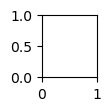

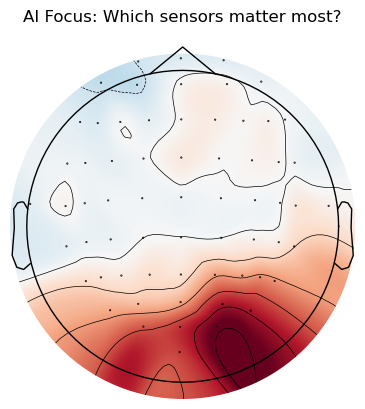

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get the raw 'importance' scores (the 576 numbers)
coefs = clf.named_steps['logisticregression'].coef_[0]

# 2. Reshape them back into (Sensors, Frequencies)
# Based on your error, we have 64 sensors
n_channels = 64
coefs_reshaped = coefs.reshape(n_channels, -1)

# 3. Average across the frequencies so we have 1 number per sensor
importance_per_sensor = coefs_reshaped.mean(axis=1)

# 4. Now draw the map!
fig, ax = plt.subplots()
mne.viz.plot_topomap(importance_per_sensor, pos=epochs_open.info, show=False, axes=ax)
ax.set_title("AI Focus: Which sensors matter most?")
plt.show()

In [23]:
import os

# Create a folder for your images if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')

# 1. Save the PSD "Skyscraper" Graph
fig_psd, ax_psd = plt.subplots(figsize=(10, 5))
raw.compute_psd(fmin=1, fmax=30).plot(axes=ax_psd, color='blue', alpha=0.5, show=False)
raw_closed.compute_psd(fmin=1, fmax=30).plot(axes=ax_psd, color='red', alpha=0.5, show=False)
ax_psd.set_title('Evidence: The 10Hz Alpha Skyscraper')
fig_psd.savefig('plots/alpha_skyscraper.png', dpi=300)

# 2. Save the AI Feature Map (The one you just made!)
fig_map, ax_map = plt.subplots()
mne.viz.plot_topomap(importance_per_sensor, pos=epochs_open.info, show=False, axes=ax_map)
ax_map.set_title("AI Focus: Occipital Lobe Importance")
fig_map.savefig('plots/ai_feature_map.png', dpi=300)

print("✅ Success! Check your 'plots' folder for the images.")

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).
✅ Success! Check your 'plots' folder for the images.
